# M7 — Image-Quality Gate & RetinaBot Assistant
**DR-Triage · Diabetic Retinopathy Stage Detection**

The value-adds that turn the classifier into a *screening tool*:

1. **Image-quality gate** (`src/quality_gate.py`) — rejects blurred, mis-exposed or
   non-fundus images *before* the model grades them, with a plain-language reason.
2. **RetinaBot** (`src/chatbot.py`) — a retrieval-grounded assistant that explains
   the prediction and answers diabetic-retinopathy questions using only cited
   snippets from screening guidance (`kb/dr_knowledge.jsonl`). It never invents
   medical claims and runs fully offline.

This notebook calibrates the gate, demonstrates both components, and runs the full
upload → gate → grade → explain pipeline end-to-end. Output feeds report §7–§8.

In [1]:
# --- Setup ---------------------------------------------------------------------
import sys, os, glob, shutil
from pathlib import Path
PROJECT = None
for cand in ["dr-triage", ".", "..", "/kaggle/working/dr-triage"]:
    if (Path(cand) / "src" / "data.py").is_file():
        PROJECT = str(Path(cand).resolve()); break
if PROJECT is None:
    hits = glob.glob("/kaggle/input/**/src/data.py", recursive=True)
    if hits:
        src_root = str(Path(hits[0]).parents[1]); PROJECT = "/kaggle/working/dr-triage"
        shutil.copytree(src_root, PROJECT, dirs_exist_ok=True)
assert PROJECT
os.chdir(PROJECT); sys.path.insert(0, PROJECT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch

from src.data import load_config, load_splits, load_labels
from src.preprocess import make_preprocessor
from src.quality_gate import QualityGate, calibrate_thresholds, METRICS

cfg = load_config()
FIG = Path(cfg["paths"]["figures_dir"]); FIG.mkdir(parents=True, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")

def read_rgb(p):
    im = cv2.imread(str(p)); return None if im is None else cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

try:
    splits = load_splits(cfg); train_df, test_df = splits["train"], splits["test"]
except FileNotFoundError:
    df = load_labels(cfg); train_df = test_df = df
print("device:", device, "| train:", len(train_df), "| test:", len(test_df))

device: mps | train: 2562 | test: 550


## 7.1  Calibrating the quality gate

The gate scores four cheap, interpretable signals — **sharpness** (variance of the
Laplacian), **brightness**, **RMS contrast**, and **field-of-view coverage** (how
much of the frame is retina rather than black). Thresholds are set just inside the
1st / 99th percentile of the *known-gradable* training images, so the gate rejects
genuine outliers, not normal variation.

calibrated thresholds (paste into config.yaml -> quality_gate.thresholds):
  sharpness    : [44.1117, .inf]
  brightness   : [27.0838, 105.728]
  contrast     : [0.0602, .inf]
  fov_coverage : [0.4739, 0.989]


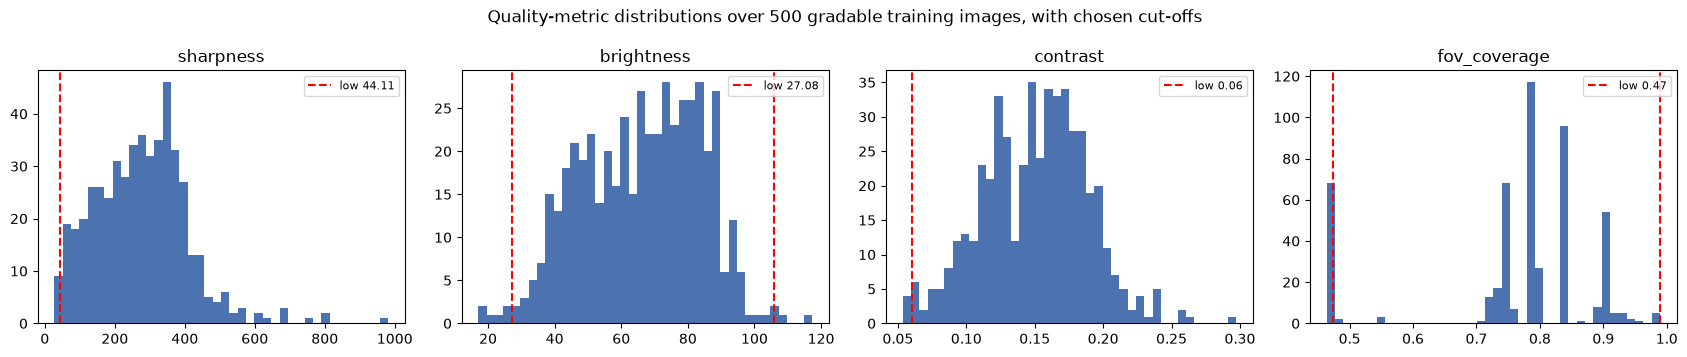

In [2]:
sample = train_df.sample(min(500, len(train_df)), random_state=cfg["seed"])
imgs = [read_rgb(p) for p in sample["path"]]
imgs = [im for im in imgs if im is not None]
vals = {k: np.array([fn(im) for im in imgs]) for k, fn in METRICS.items()}
calib = calibrate_thresholds(imgs, low_pct=1.0, high_pct=99.5)  # permissive upper bounds

print("calibrated thresholds (paste into config.yaml -> quality_gate.thresholds):")
for k, (lo, hi) in calib.items():
    print(f"  {k:13s}: [{lo}, {'.inf' if hi == float('inf') else round(hi,3)}]")

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (k, v) in zip(axes, vals.items()):
    ax.hist(v, bins=40, color="#4c72b0")
    lo, hi = calib[k]
    ax.axvline(lo, color="red", ls="--", label=f"low {lo:.2f}")
    if hi != float("inf"):
        ax.axvline(hi, color="red", ls="--")
    ax.set_title(k); ax.legend(fontsize=8)
plt.suptitle("Quality-metric distributions over 500 gradable training images, with chosen cut-offs")
plt.tight_layout(); plt.savefig(FIG / "07_quality_calibration.png", dpi=150); plt.show()

gate = QualityGate(calib)   # use the freshly calibrated thresholds for this session

## 7.2  The gate in action — good images vs degraded copies

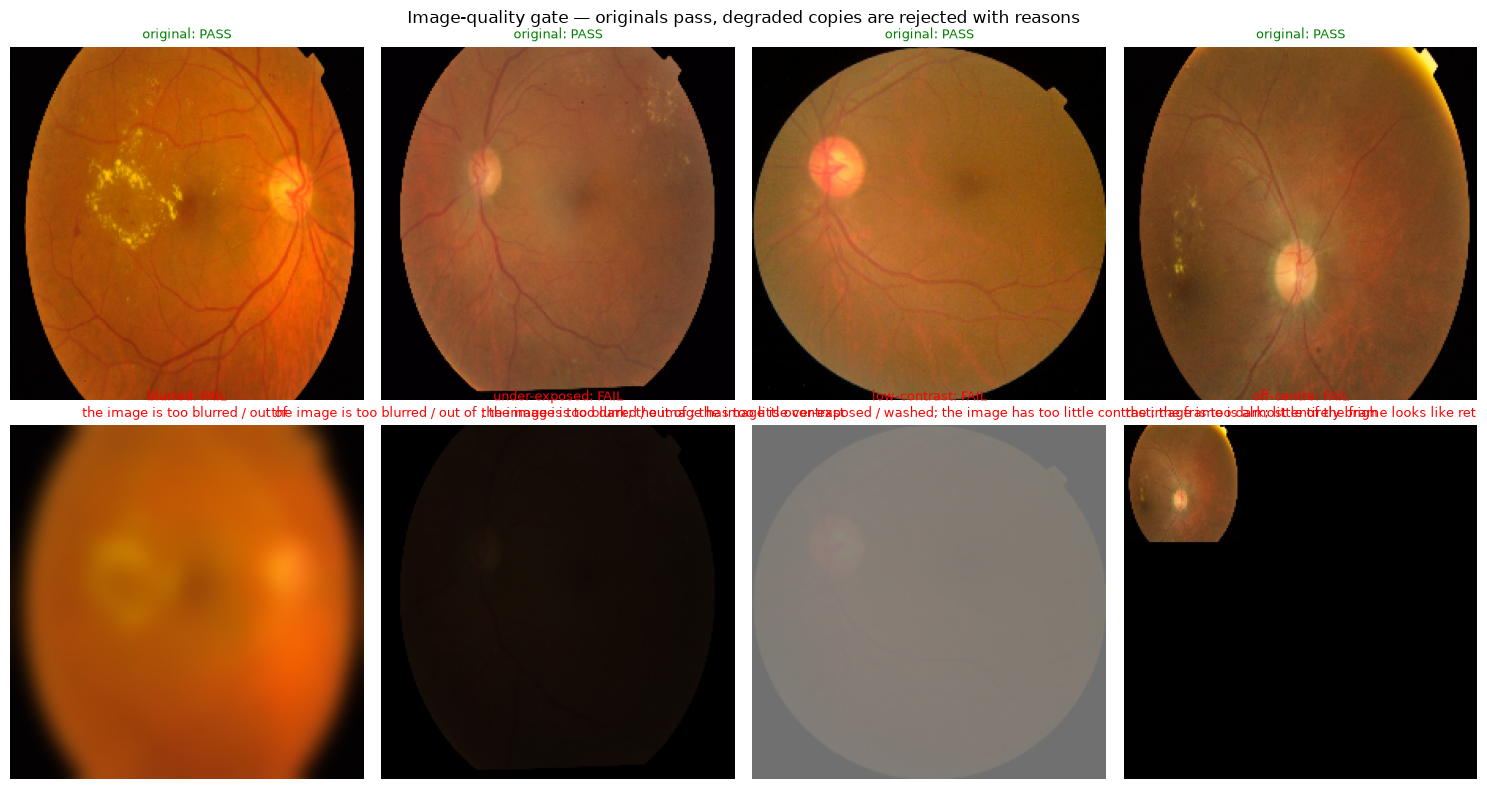

In [3]:
good = [read_rgb(p) for p in test_df.sample(4, random_state=1)["path"]]

def degrade(img, how):
    if how == "blurred":      return cv2.GaussianBlur(img, (41, 41), 0)
    if how == "under-exposed":return np.clip(img * 0.14, 0, 255).astype(np.uint8)
    if how == "low-contrast": return np.clip(128 + (img.astype(float) - 128) * 0.12, 0, 255).astype(np.uint8)
    if how == "off-centre":   # retina shoved into a corner -> low FOV coverage
        z = np.zeros_like(img); h, w = img.shape[:2]
        z[:h//3, :w//3] = cv2.resize(img, (w//3, h//3)); return z
    return img

cases = [(g, "original") for g in good] + \
        [(degrade(good[i], h), h) for i, h in enumerate(["blurred", "under-exposed", "low-contrast", "off-centre"])]

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, (im, label) in zip(axes.ravel(), cases):
    r = gate.assess(im)
    ax.imshow(im); ax.axis("off")
    title = f"{label}: {'PASS' if r.passed else 'FAIL'}"
    sub = "" if r.passed else "\n" + "; ".join(x.split(' — ')[0].split(' (')[0][:34] for x in r.reasons)
    ax.set_title(title + sub, fontsize=9, color="green" if r.passed else "red")
plt.suptitle("Image-quality gate — originals pass, degraded copies are rejected with reasons")
plt.tight_layout(); plt.savefig(FIG / "07_quality_gate.png", dpi=150, bbox_inches="tight"); plt.show()

## 7.3  RetinaBot — retrieval-grounded, cited, offline

Every answer is either a statement about *this* prediction (from the model's own
output) or a verbatim guideline snippet with its source tag. If nothing in the
knowledge base is relevant enough, the bot declines rather than guess. First run
downloads the MiniLM encoder (~90 MB).

In [4]:
from src.chatbot import RetinaBot
bot = RetinaBot(kb_path=cfg["chatbot"]["kb_path"],
                model_name=cfg["chatbot"]["encoder"],
                min_score=cfg["chatbot"]["min_score"],
                top_k=cfg["chatbot"]["top_k"])
print(f"knowledge base: {len(bot.snippets)} snippets | FAISS index: {bot._faiss}\n")

for q in ["What does moderate NPDR mean and should I see a doctor?",
          "How often should someone with diabetes have their eyes screened?",
          "What are the risk factors for diabetic retinopathy getting worse?",
          "Which football team should I support?"]:      # <- off-topic: bot should decline
    out = bot.answer(q)
    print("Q:", q)
    print(out["answer"])
    print("retrieved:", out["retrieved"])
    print("=" * 78)

/Users/ilmeedesilva/Computer Vision/dr-triage/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2154.45it/s]


knowledge base: 20 snippets | FAISS index: True

Q: What does moderate NPDR mean and should I see a doctor?
From diabetic-retinopathy screening guidance:

• Moderate non-proliferative diabetic retinopathy shows microaneurysms together with dot-and-blot haemorrhages and often hard exudates. It is generally considered referable disease: the patient should be seen by an ophthalmologist for assessment and closer follow-up. _[ICO]_

• Referral urgency rises with severity: moderate retinopathy is a routine ophthalmology referral, severe non-proliferative retinopathy is a prompt referral, and proliferative retinopathy or sight-threatening maculopathy is an urgent or emergency referral. _[AAO]_

• In most screening programmes, 'referable diabetic retinopathy' means moderate non-proliferative disease or worse (grade 2 and above), or any diabetic maculopathy. Grades 0 and 1 are usually managed by routine re-screening rather than referral. _[NHS DESP]_

_This is general information from screening

## 7.4  End-to-end: upload → quality gate → grade → explain

In [5]:
from src.model import DRModel, predict_stage
from src.augment import build_eval_aug
from src import evaluate as E

# one trained fold model is enough for the demo
try:
    model = E.load_fold_models(cfg, device)[0]
    trained = True
except FileNotFoundError:
    model = DRModel(cfg, pretrained=False).to(device).eval(); trained = False
pre = make_preprocessor(cfg)
S = cfg["image"]["size_stage2"]; MEAN, STD = cfg["image"]["mean"], cfg["image"]["std"]

def run_pipeline(img_rgb, follow_up=None):
    print("STEP 1 — quality gate")
    qr = gate.assess(img_rgb)
    print("  " + qr.as_text().replace("\n", "\n  "))
    if not qr.passed:
        return
    print("\nSTEP 2 — preprocess + grade")
    x = build_eval_aug(S, MEAN, STD)(image=pre(img_rgb))["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(x); p = predict_stage(out)
    stage = int(p["ordinal_pred"]); conf = float(p["softmax_prob"][0, stage])
    refp = float(p["referable_prob"])
    print(f"  predicted stage: {stage} ({cfg['classes'][stage]}) | confidence {conf:.0%} | referable p {refp:.0%}")
    print("\nSTEP 3 — RetinaBot explanation")
    ctx = {"stage": stage, "referable_prob": refp, "confidence": conf}
    print(bot.answer("What does this result mean for me?", result_context=ctx)["answer"])
    if follow_up:
        print("\nPATIENT:", follow_up)
        print(bot.answer(follow_up, result_context=ctx)["answer"])

row = test_df[test_df["stage"] == 2].iloc[0]
print(f"(true grade of this image: {row['stage']} = {row['stage_name']}; model is "
      f"{'trained' if trained else 'UNTRAINED — demo only'})\n")
run_pipeline(read_rgb(row["path"]),
            follow_up="Can I keep driving, and when should I be seen?")

loaded 3 fold checkpoint(s): ['fold0_best.pt', 'fold1_best.pt', 'fold2_best.pt']
(true grade of this image: 2 = Moderate; model is trained)

STEP 1 — quality gate
  Image quality OK — proceeding to grading.

STEP 2 — preprocess + grade
  predicted stage: 1 (Mild) | confidence 24% | referable p 82%

STEP 3 — RetinaBot explanation
The model graded this image as **Mild NPDR (stage 1)** — earliest changes (microaneurysms). Usually managed by tighter diabetes control and continued screening, not referral. Model confidence for this grade: 24%. Referable-DR probability: 82% → suggested action: **refer**.

Guidance relevant to this result:

• Mild non-proliferative diabetic retinopathy means only microaneurysms (tiny bulges in retinal capillaries) are present. Vision is usually unaffected. Management is tighter control of blood glucose, blood pressure and cholesterol, with continued annual or more frequent screening. _[AAO]_

• Moderate non-proliferative diabetic retinopathy shows microaneurys

## 7.5  Prototype app (M8)

`app/app.py` (built in M8) wraps exactly this pipeline in a Gradio interface:

`upload fundus image → quality gate (reject with reason, or) → preprocessing
preview → stage + referable + calibrated confidence → Grad-CAM++ overlay →
RetinaBot Q&A`

plus an optional batch mode that scores a folder and returns a CSV triage list
sorted by severity. The hosted demonstration video walks through it.

## 7.6  Report §7 — Innovation, Practical Impact & Critical Discussion  *(draft)*

**What makes this more than a classifier.**
1. *Order-aware modelling* — the CORAL ordinal head plus a soft-Quadratic-Weighted-Kappa
   loss term make the training objective itself distance-aware, so the model is
   optimised for the metric clinicians actually use (§4, §6.11).
2. *A referral decision, not just a grade* — a dedicated binary head outputs the
   refer / re-screen action with a tunable operating point (§6.6): at threshold
   0.40 it reaches ~0.97 sensitivity for referable disease.
3. *Trustable confidence* — temperature-scaled probabilities (ECE 0.079) and an
   MC-dropout uncertainty score that lets the least-confident cases be routed to a
   human (§6.7–6.8).
4. *Won't grade what it can't see* — the image-quality gate rejects ungradable
   uploads with a specific reason, the single biggest failure mode of real
   screening software.
5. *Explains itself two ways* — Grad-CAM++ shows *where* it looked; RetinaBot
   explains *what the result means* and answers follow-up questions using only
   cited guideline snippets, never unsourced generation.

**Real-world impact.** DR screening is limited by grader capacity; a triage tool
that safely clears the ~50 % of images that are clearly No-DR and flags the rest,
with an explanation and a confidence, directly relieves that bottleneck. The model
is small (20 M parameters) and runs on a CPU in well under a second per image, so
it is deployable at the point of care or on a modest server.

**Deployment feasibility & limitations.** Trained and validated on a single
population (rural India) and a single image style at 224 px; performance on other
cameras or demographics is unknown and would need local re-validation and
re-calibration. It is not a regulated medical device. The weak Moderate-class
recall (§6.3) means borderline cases should always reach a human. Automation bias
is a real risk and is mitigated — not removed — by the explanation, confidence and
uncertainty outputs.

**Ethics.** De-identified data; screening aid framing on every output; explicit
"see a professional / seek same-day care for warning signs" notice from the
assistant; fairness caveat stated as a deployment pre-condition.

**Future work.** Higher-resolution source images to recover Mild↔Moderate
discrimination; lesion-level supervision (e.g. IDRiD masks) to sharpen and verify
Grad-CAM; external validation on a second dataset; an optional LLM phrasing layer
for the assistant that is constrained to change no facts and keep every citation.

## Milestone status
- [x] M1–M6 complete
- [x] **M7 — quality gate + RetinaBot**, figures in `outputs/figures/`
- [ ] M8 — Gradio app (`app/app.py`) + record demo video + finalise report